In [60]:
import numpy as np
import torch
import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data generation
from src.data_generation.realistic_world import simulate_realistic_world

# Training utilities
from src.training.preprocessing import split_data, scale_data
from src.training.train_lr import train_logistic_regression
from src.training.train_mlp import train_mlp_model, plot
from src.training.train_mlp import MLP_Realistic, MLP, train_mlp_model


# Fairness metrics
from src.metrics.fairness import fairness_by_group, equal_opportunity_diff


In [62]:
df = simulate_realistic_world(n_samples=10000, seed=SEED)


df.head()


,race,gender,age,ses,bmi,glucose_true,hba1c_true,glucose_measured,hba1c_measured,diabetes_true,diabetes_label
0,0,0,70.169189,0.381160,26.961787,94.888234,5.330995,84.337000,5.405459,0,0
1,2,1,49.973046,-0.780090,29.862743,89.706288,5.717056,91.350209,5.686007,1,1
2,1,1,40.183974,-0.318449,27.315790,93.981328,5.320664,96.036258,5.084547,1,1
3,0,1,51.476224,0.575729,27.047767,90.775143,5.748412,84.958016,5.839906,0,0
4,0,0,43.393592,1.191135,29.044337,78.164894,5.543759,65.419455,6.030847,0,0


In [68]:
df.to_csv("df_realistic.csv", index=False)

print("Datasets saved!")

Datasets saved!


In [63]:
# Realistic world features
features = [
    "glucose_measured",
    "hba1c_measured",
    "age",
    "bmi",
    "ses"
]

target = "diabetes_label"

X_train, X_test, y_train, y_test = split_data(df, features, target)

X_train_s, X_test_s, scaler = scale_data(X_train, X_test)

print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("Train prevalence:", y_train.mean())
print("Test prevalence:", y_test.mean())


Train size: 8000
Test size: 2000
Train prevalence: 0.498
Test prevalence: 0.4925


In [64]:
lr_results = train_logistic_regression(
    X_train_s, y_train,
    X_test_s, y_test
)

print("LR Accuracy:", lr_results["accuracy"])
print("LR AUROC:", lr_results["AUROC"])


LR Accuracy: 0.7
LR AUROC: 0.7482283513790602


Epoch 1/50: train_loss=0.5723, train_acc=71.84, val_loss=0.5462, val_acc=73.80
Epoch 2/50: train_loss=0.5405, train_acc=74.29, val_loss=0.5430, val_acc=73.40
Epoch 3/50: train_loss=0.5363, train_acc=74.70, val_loss=0.5439, val_acc=73.65
Epoch 4/50: train_loss=0.5339, train_acc=74.24, val_loss=0.5385, val_acc=73.90
Epoch 5/50: train_loss=0.5311, train_acc=74.75, val_loss=0.5375, val_acc=74.05
Epoch 6/50: train_loss=0.5317, train_acc=74.61, val_loss=0.5387, val_acc=73.90
Epoch 7/50: train_loss=0.5299, train_acc=74.53, val_loss=0.5427, val_acc=73.85
Epoch 8/50: train_loss=0.5286, train_acc=74.65, val_loss=0.5403, val_acc=73.45
Epoch 9/50: train_loss=0.5271, train_acc=74.94, val_loss=0.5401, val_acc=73.50
Epoch 10/50: train_loss=0.5276, train_acc=75.03, val_loss=0.5386, val_acc=73.75
Epoch 11/50: train_loss=0.5252, train_acc=75.00, val_loss=0.5438, val_acc=73.95
Epoch 12/50: train_loss=0.5260, train_acc=74.89, val_loss=0.5419, val_acc=73.65
Epoch 13/50: train_loss=0.5251, train_acc=75.06, 

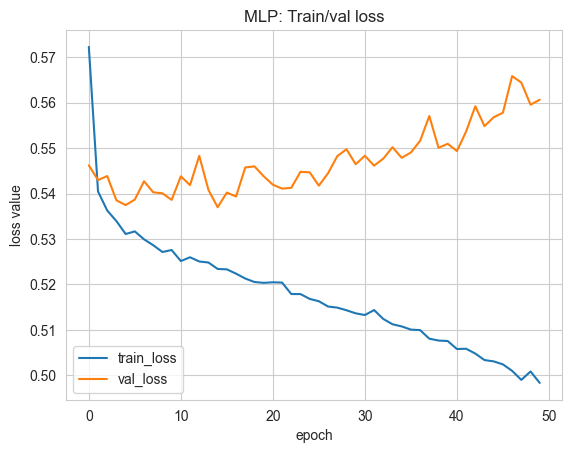

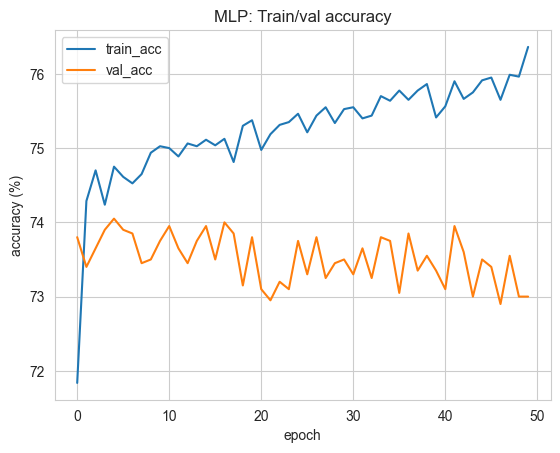

In [65]:
mlp_results = train_mlp_model(
    X_train_s, y_train,
    X_test_s, y_test,
    input_dim=len(features),
    model_class=MLP_Realistic,# <-- use large model here!
    n_epochs=50,                 # train longer
    lr=0.001
)


print("MLP Accuracy:", mlp_results["accuracy"])
print("MLP AUROC:", mlp_results["AUROC"])


In [69]:
mlp_train_real = mlp_results["train_losses"]
mlp_val_real = mlp_results["val_losses"]

with open("mlp_realistic_curves.json", "w") as f:
    json.dump({
        "train_losses": mlp_train_real,
        "val_losses": mlp_val_real
    }, f)


In [57]:
df_test = df.loc[X_test.index].copy()

print("=== LR Fairness by Race ===")
lr_fair_race = fairness_by_group(y_test, lr_results["pred"], df_test["race"])
print(lr_fair_race)

print("\n=== LR Fairness by Gender ===")
lr_fair_gender = fairness_by_group(y_test, lr_results["pred"], df_test["gender"])
print(lr_fair_gender)

LR_EO_race = equal_opportunity_diff(lr_fair_race)
LR_EO_gender = equal_opportunity_diff(lr_fair_gender)



print("\n=== MLP Fairness by Race ===")
mlp_fair_race = fairness_by_group(y_test, mlp_results["pred"], df_test["race"])
print(mlp_fair_race)

print("\n=== MLP Fairness by Gender ===")
mlp_fair_gender = fairness_by_group(y_test, mlp_results["pred"], df_test["gender"])
print(mlp_fair_gender)

MLP_EO_race   = equal_opportunity_diff(mlp_fair_race)
MLP_EO_gender = equal_opportunity_diff(mlp_fair_gender)


=== LR Fairness by Race ===
        FPR       FNR       TPR       TNR
0  0.162500  0.619048  0.380952  0.837500
1  0.714286  0.105263  0.894737  0.285714
2  1.000000  0.000000  1.000000  0.000000

=== LR Fairness by Gender ===
        FPR       FNR       TPR       TNR
0  0.322034  0.325581  0.674419  0.677966
1  0.311111  0.301887  0.698113  0.688889

=== MLP Fairness by Race ===
        FPR       FNR       TPR       TNR
0  0.200000  0.428571  0.571429  0.800000
1  0.714286  0.105263  0.894737  0.285714
2  1.000000  0.062500  0.937500  0.000000

=== MLP Fairness by Gender ===
        FPR       FNR       TPR       TNR
0  0.338983  0.255814  0.744186  0.661017
1  0.355556  0.226415  0.773585  0.644444


In [73]:
mlp_fair_race.to_json("realistic_tpr_by_race.json", orient="index")
print("Saved realistic TPR-by-race → realistic_tpr_by_race.json")

Saved realistic TPR-by-race → realistic_tpr_by_race.json


In [58]:
results_realistic = {
    "world_name": "Realistic",
    "LR_accuracy": lr_results["accuracy"],
    "LR_AUROC": lr_results["AUROC"],
    "LR_EO_race": LR_EO_race,
    "LR_EO_gender": LR_EO_gender,

    "MLP_accuracy": mlp_results["accuracy"],
    "MLP_AUROC": mlp_results["AUROC"],
    "MLP_EO_race": MLP_EO_race,
    "MLP_EO_gender": MLP_EO_gender,
}

results_realistic


{'world_name': 'Realistic',
 'LR_accuracy': 0.685,
 'LR_AUROC': 0.7470953525641026,
 'LR_EO_race': 0.6190476190476191,
 'LR_EO_gender': 0.023694602896007,
 'MLP_accuracy': np.float64(0.705),
 'MLP_AUROC': 0.7271634615384616,
 'MLP_EO_race': 0.3660714285714286,
 'MLP_EO_gender': 0.029398859148749512}

In [67]:
results_realistic = {
    "world_name": "Realistic",
    "LR_accuracy": lr_results["accuracy"],
    "LR_AUROC": lr_results["AUROC"],
    "LR_EO_race": LR_EO_race,
    "LR_EO_gender": LR_EO_gender,
    "MLP_accuracy": mlp_results["accuracy"],
    "MLP_AUROC": mlp_results["AUROC"],
    "MLP_EO_race": MLP_EO_race,
    "MLP_EO_gender": MLP_EO_gender,
}

json.dump(results_realistic, open("results_realistic.json", "w"), indent=4)
print("Saved Realistic world → results_realistic.json")


Saved Realistic world → results_realistic.json
